# GRIDWORLD B

In [1]:
import numpy as np
import random
import matplotlib.pyplot as plt

class GridWorldB:
    def __init__(self, width, height, start, goal, wind):
        self.width = width
        self.height = height
        self.start = start
        self.goal = goal
        self.wind = wind  # list of wind strengths per column
        self.state = start

    def reset(self):
        self.state = self.start
        return self.state

    def step(self, action):
        x, y = self.state
        if action == 0:   x = max(x - 1, 0)
        elif action == 1: x = min(x + 1, self.height - 1)
        elif action == 2: y = max(y - 1, 0)
        elif action == 3: y = min(y + 1, self.width - 1)
        elif action == 4: x = max(x - 1, 0);  y = max(y - 1, 0)   
        elif action == 5: x = max(x - 1, 0);  y = min(y + 1, self.width - 1)  
        elif action == 6: x = min(x + 1, self.height - 1); y = max(y - 1, 0)  
        elif action == 7: x = min(x + 1, self.height - 1); y = min(y + 1, self.width - 1)

        # apply wind: shifts agent upward (decreases row index)
        x = max(x - self.wind[y], 0)

        next_state = (x, y)

        if next_state == self.goal:
            reward = 1
            done = True
        else:
            reward = -1
            done = False

        self.state = next_state
        return next_state, reward, done

## Algorithms

In [2]:
def epsilon_greedy_policy(Q, state, epsilon):
    if random.uniform(0, 1) < epsilon:
        return random.randint(0, 7)  # Explore: choose a random action
    else:
        q_values = Q[state[0], state[1]]
        max_q = np.max(q_values)
        best_actions = np.where(q_values == max_q)[0]
        return random.choice(best_actions)  # Exploit: choose the best action

In [3]:
def sarsa(env, episodes, alpha, gamma, epsilon, max_steps=500):
    Q = np.zeros((env.height, env.width, 8))
    steps_per_episode = []
    rewards_per_episode = []

    for episode in range(episodes):
        state = env.reset()
        action = epsilon_greedy_policy(Q, state, epsilon)
        done = False
        total_reward = 0
        steps = 0

        while not done and steps < max_steps:
            next_state, reward, done = env.step(action)
            next_action = epsilon_greedy_policy(Q, next_state, epsilon)
            Q[state[0], state[1], action] += alpha * (reward + gamma * Q[next_state[0], next_state[1], next_action] - Q[state[0], state[1], action])
            state = next_state
            action = next_action
            total_reward += reward
            steps += 1

        steps_per_episode.append(steps)
        rewards_per_episode.append(total_reward)

    return Q, steps_per_episode, rewards_per_episode


In [9]:
def sarsa4(env, episodes, alpha, gamma, epsilon, max_steps=500):
        Q = np.zeros((env.height, env.width, 4))
        steps_per_episode = []
        rewards_per_episode = []
        for episode in range(episodes):
            state = env.reset()
            action = random.randint(0, 3) if random.random() < epsilon else int(np.argmax(Q[state[0], state[1]]))
            done = False
            total_reward = 0
            steps = 0
            while not done and steps < max_steps:
                next_state, reward, done = env.step(action)
                q_vals = Q[next_state[0], next_state[1]]
                next_action = random.randint(0, 3) if random.random() < epsilon else random.choice(np.where(q_vals == np.max(q_vals))[0])
                Q[state[0], state[1], action] += alpha * (
                    reward + gamma * Q[next_state[0], next_state[1], next_action]
                    - Q[state[0], state[1], action]
                )
                state = next_state
                action = next_action
                total_reward += reward
                steps += 1
            steps_per_episode.append(steps)
            rewards_per_episode.append(total_reward)
        return Q, steps_per_episode, rewards_per_episode

    

In [8]:
def evaluate4(env, Q, trials=100, max_steps=500):
        steps_list = []
        for _ in range(trials):
            state = env.reset()
            done = False
            steps = 0
            while not done and steps < max_steps:
                q_vals = Q[state[0], state[1]]
                action = random.choice(np.where(q_vals == np.max(q_vals))[0])
                state, _, done = env.step(action)
                steps += 1
            steps_list.append(steps)
        return np.mean(steps_list), np.std(steps_list)

In [4]:
def evaluate(env, Q, trials=100, max_steps=500):
    steps_list = []
    for _ in range(trials):
        state = env.reset()
        done = False
        steps = 0
        while not done and steps < max_steps:
            action = epsilon_greedy_policy(Q, state, epsilon=0)
            state, _, done = env.step(action)
            steps += 1
        steps_list.append(steps)
    return np.mean(steps_list), np.std(steps_list)


In [5]:
def smooth(data, window=50):
    kernel = np.ones(window) / window
    return np.convolve(data, kernel, mode='valid')

def convergence_time(steps_per_episode, buffer=30, window=50):
    optimal = min(steps_per_episode)
    threshold = optimal + buffer
    smoothed = smooth(steps_per_episode, window)
    for i, val in enumerate(smoothed):
        if val <= threshold:
            return i + window
    return len(steps_per_episode)  # never converged

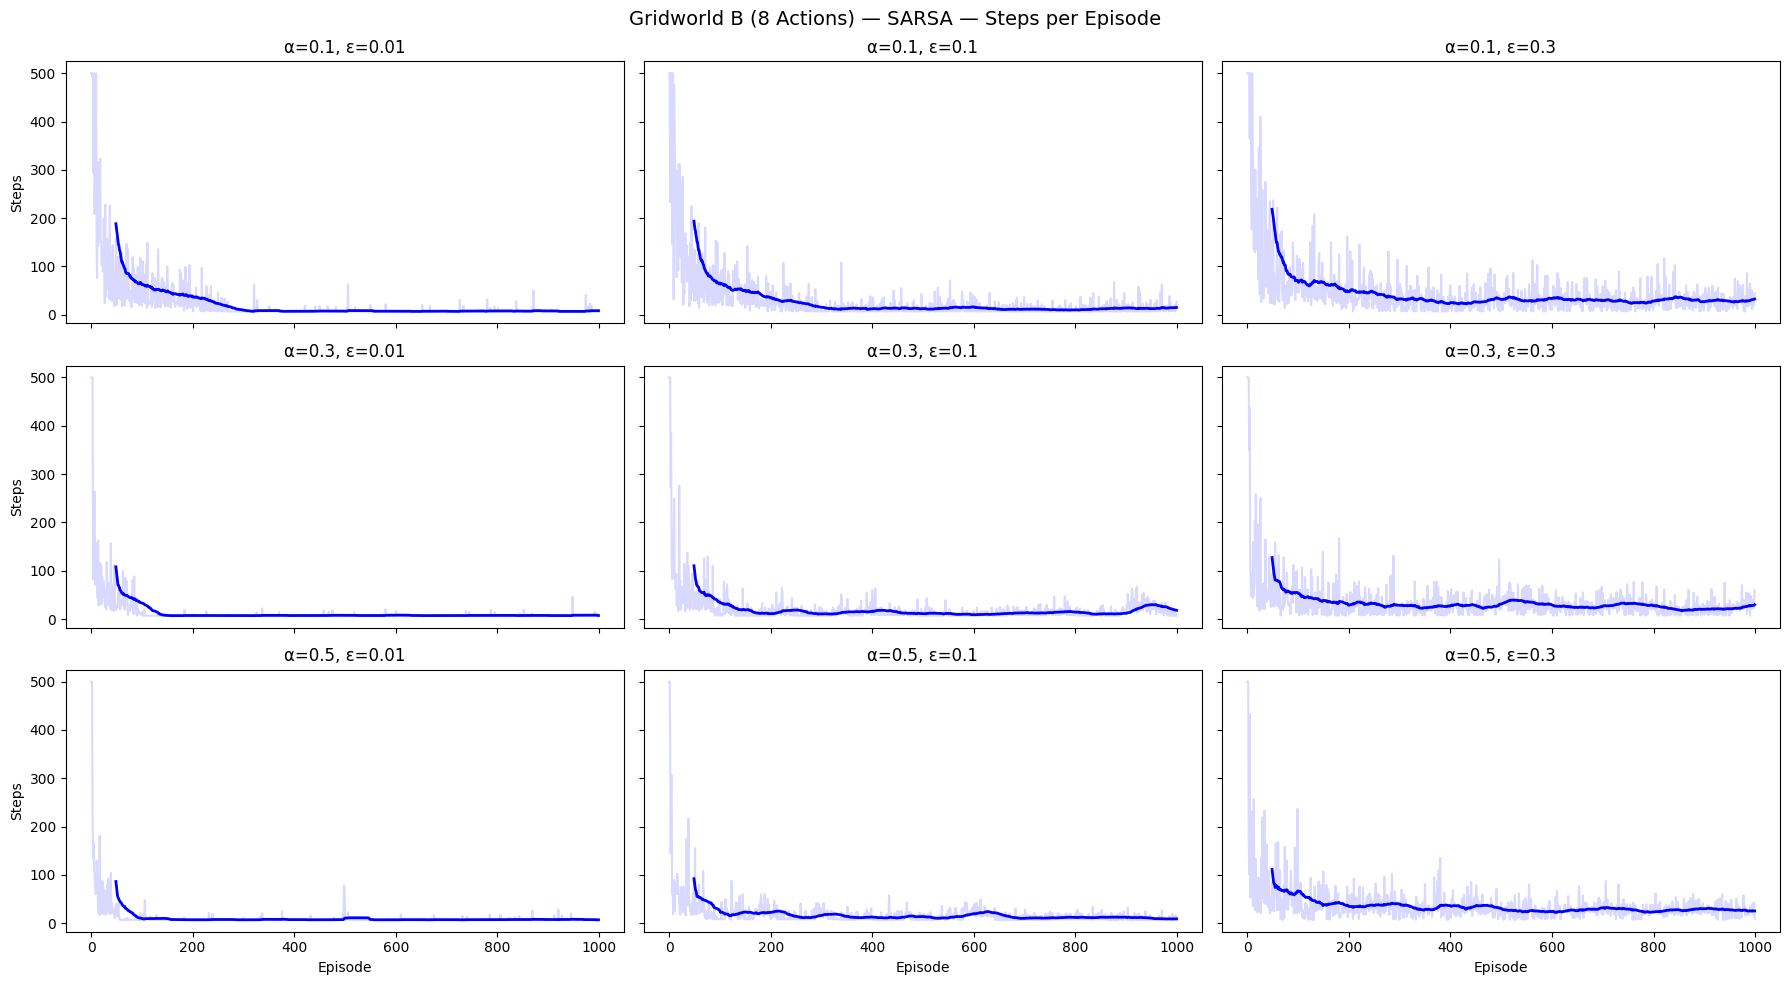

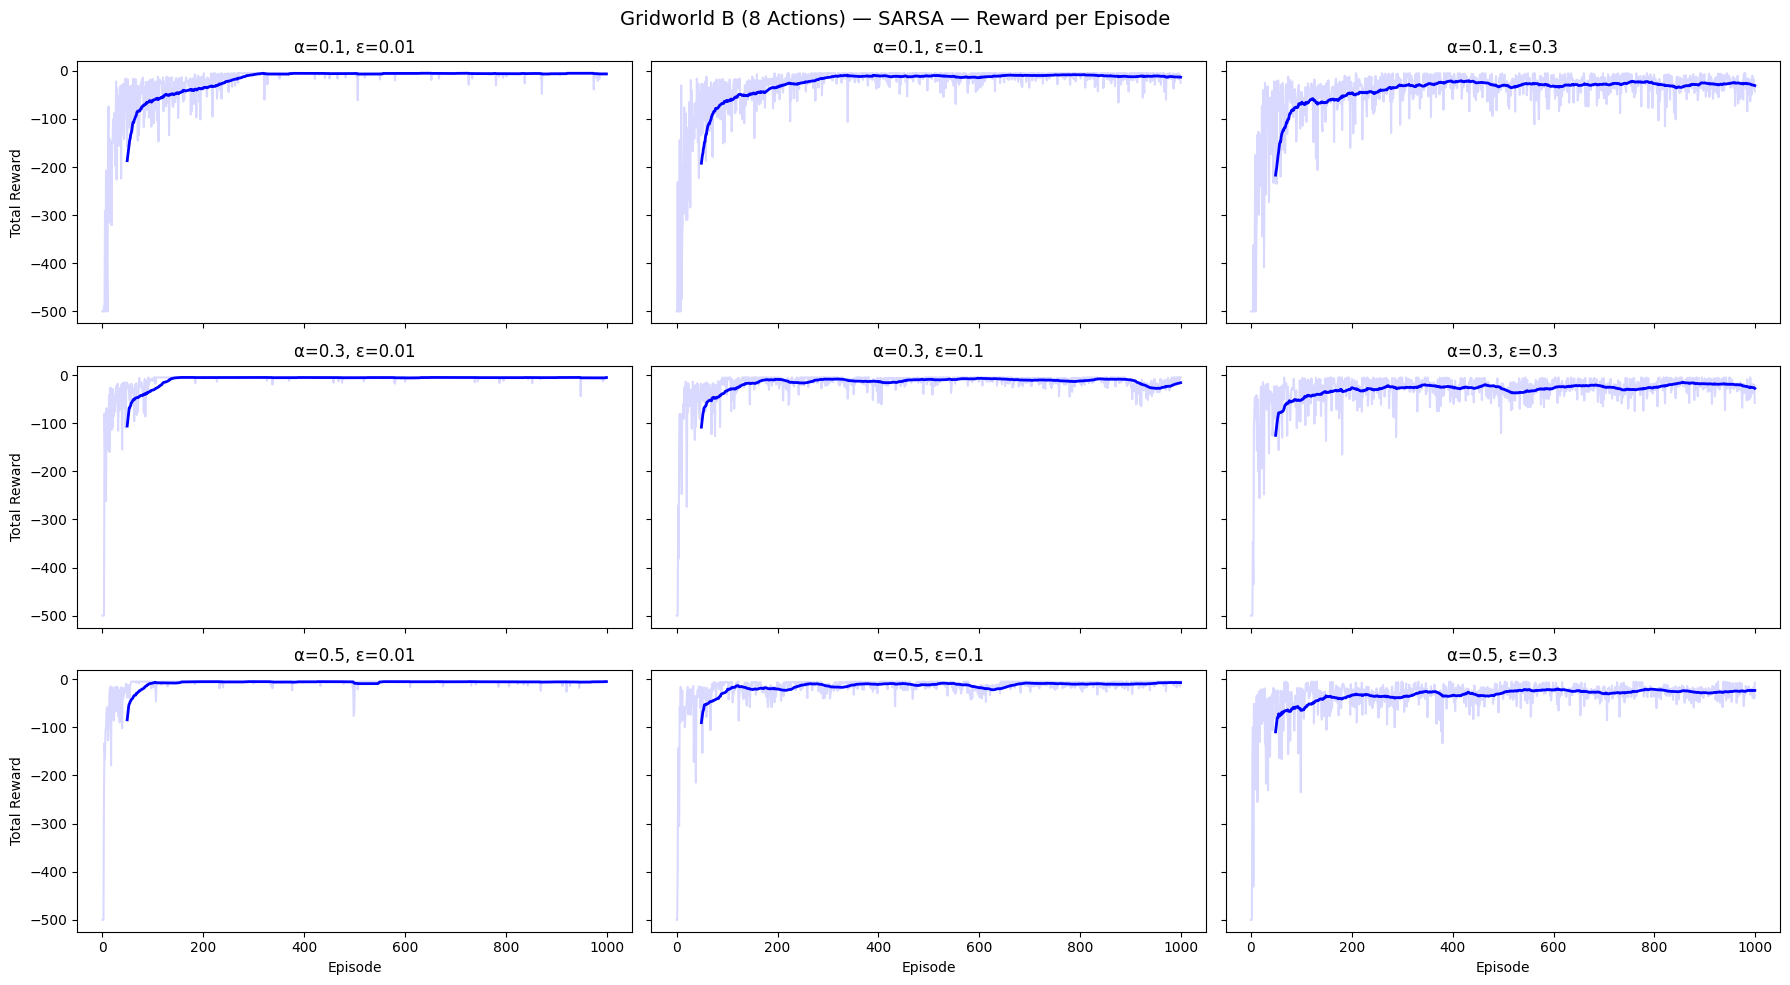

CONVERGENCE TIME — SARSA 8 Actions
α      ε       Conv. Episode
------------------------------
0.1    0.01              202
0.1    0.1               190
0.1    0.3               276
0.3    0.01               94
0.3    0.1                97
0.3    0.3               147
0.5    0.01               63
0.5    0.1                89
0.5    0.3               150

PATH EFFICIENCY — SARSA 8 Actions (avg steps, 100 greedy trials)
α      ε       Avg Steps
--------------------------
0.1    0.01         7.00
0.1    0.1          7.00
0.1    0.3        500.00
0.3    0.01         7.00
0.3    0.1          7.00
0.3    0.3        500.00
0.5    0.01         7.00
0.5    0.1          7.00
0.5    0.3          8.00

ROBUSTNESS — SARSA 8 Actions (std dev across 10 seeds)
α      ε       Avg Steps    Std Dev
------------------------------------
0.1    0.01         7.00       0.00
0.1    0.1          7.00       0.00
0.1    0.3        106.00     197.00
0.3    0.01         7.00       0.00
0.3    0.1        106.10    

In [10]:
if __name__ == "__main__":

    width = 10
    height = 7
    start = (3, 0)
    goal = (3, 7)
    wind = [0, 0, 0, 1, 1, 1, 2, 2, 1, 0]
    env = GridWorldB(width, height, start, goal, wind)

    episodes = 1000
    gamma = 1.0

    epsilons = [0.01, 0.1, 0.3]
    alphas = [0.1, 0.3, 0.5]

    # --- Train SARSA (8 actions) ---
    results = {}
    for alpha in alphas:
        for eps in epsilons:
            Q, steps, rewards = sarsa(env, episodes, alpha=alpha, gamma=gamma, epsilon=eps)
            results[(alpha, eps)] = (Q, steps, rewards)

    # --- Learning curves: Steps per episode ---
    fig, axes = plt.subplots(len(alphas), len(epsilons), figsize=(18, 10), sharex=True, sharey=True)
    fig.suptitle("Gridworld B (8 Actions) — SARSA — Steps per Episode", fontsize=14)
    for i, alpha in enumerate(alphas):
        for j, eps in enumerate(epsilons):
            ax = axes[i][j]
            _, steps, _ = results[(alpha, eps)]
            ax.plot(steps, color="blue", alpha=0.15)
            ax.plot(range(49, len(steps)), smooth(steps), color="blue", linewidth=2)
            ax.set_title(f"α={alpha}, ε={eps}")
            if i == len(alphas) - 1: ax.set_xlabel("Episode")
            if j == 0: ax.set_ylabel("Steps")
    plt.tight_layout()
    plt.show()

    # --- Learning curves: Reward per episode ---
    fig, axes = plt.subplots(len(alphas), len(epsilons), figsize=(18, 10), sharex=True, sharey=True)
    fig.suptitle("Gridworld B (8 Actions) — SARSA — Reward per Episode", fontsize=14)
    for i, alpha in enumerate(alphas):
        for j, eps in enumerate(epsilons):
            ax = axes[i][j]
            _, _, rewards = results[(alpha, eps)]
            ax.plot(rewards, color="blue", alpha=0.15)
            ax.plot(range(49, len(rewards)), smooth(rewards), color="blue", linewidth=2)
            ax.set_title(f"α={alpha}, ε={eps}")
            if i == len(alphas) - 1: ax.set_xlabel("Episode")
            if j == 0: ax.set_ylabel("Total Reward")
    plt.tight_layout()
    plt.show()

    # --- Convergence Time ---
    print("CONVERGENCE TIME — SARSA 8 Actions")
    print(f"{'α':<6} {'ε':<6} {'Conv. Episode':>14}")
    print("-" * 30)
    for alpha in alphas:
        for eps in epsilons:
            _, steps, _ = results[(alpha, eps)]
            print(f"{alpha:<6} {eps:<6} {convergence_time(steps):>14}")
    print()

    # --- Path Efficiency ---
    print("PATH EFFICIENCY — SARSA 8 Actions (avg steps, 100 greedy trials)")
    print(f"{'α':<6} {'ε':<6} {'Avg Steps':>10}")
    print("-" * 26)
    for alpha in alphas:
        for eps in epsilons:
            Q, _, _ = results[(alpha, eps)]
            mean, _ = evaluate(env, Q)
            print(f"{alpha:<6} {eps:<6} {mean:>10.2f}")
    print()

    # --- Robustness ---
    n_seeds = 10
    print("ROBUSTNESS — SARSA 8 Actions (std dev across 10 seeds)")
    print(f"{'α':<6} {'ε':<6} {'Avg Steps':>10} {'Std Dev':>10}")
    print("-" * 36)
    for alpha in alphas:
        for eps in epsilons:
            seed_means = []
            for seed in range(n_seeds):
                random.seed(seed); np.random.seed(seed)
                Q, _, _ = sarsa(env, episodes, alpha=alpha, gamma=gamma, epsilon=eps)
                mean, _ = evaluate(env, Q)
                seed_means.append(mean)
            print(f"{alpha:<6} {eps:<6} {np.mean(seed_means):>10.2f} {np.std(seed_means):>10.2f}")
    print()

    # --- Comparison: SARSA 4-action (Task 1) vs SARSA 8-action (Task 2) ---
    # Paste the Task 1 SARSA results here manually after running gridworldB.ipynb,
    # or re-run them inline:
    results4 = {}
    for alpha in alphas:
        for eps in epsilons:
            Q, steps, rewards = sarsa4(env, episodes, alpha=alpha, gamma=gamma, epsilon=eps)
            results4[(alpha, eps)] = (Q, steps, rewards)

    print("=" * 60)
    print("COMPARISON: SARSA 4-Action vs SARSA 8-Action")
    print("=" * 60)

    print(f"\n{'α':<6} {'ε':<6} {'Conv-4':>8} {'Conv-8':>8} {'Steps-4':>9} {'Steps-8':>9}")
    print("-" * 48)
    for alpha in alphas:
        for eps in epsilons:
            _, s4, _ = results4[(alpha, eps)]
            _, s8, _ = results[(alpha, eps)]
            Q4, _, _ = results4[(alpha, eps)]
            Q8, _, _ = results[(alpha, eps)]
            c4 = convergence_time(s4)
            c8 = convergence_time(s8)
            m4, _ = evaluate4(env, Q4)
            m8, _ = evaluate(env, Q8)
            print(f"{alpha:<6} {eps:<6} {c4:>8} {c8:>8} {m4:>9.2f} {m8:>9.2f}")